# This notebook compares performance between SAPINNScalarTrainer (a simplification based on McCleny et al's "Self-Adaptive Physics-Informed Neural Networks using a Soft Attention Mechanism" https://arxiv.org/abs/2211.13227) and PDETrainer (our older model where loss coefficients are chosen & non-adaptive)

Imports

In [27]:
import numpy as np
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

import importlib
importlib.reload(mlps)
importlib.reload(trainer)
importlib.reload(hlprs)

<module 'prog.hlprs' from 'c:\\Users\\Ethan\\Desktop\\Research\\pde_stuff\\ethan_work\\..\\prog\\hlprs.py'>

Hyperparameter initialization, Building dataset

In [2]:
# recall that from our sweeping tests, we got lambda_tv_star to be around 10e-6.
# we will attempt to learn lam_tv and lam_pde
# initialize lambda_tv, lambda_pde as 1 (the paper doesn't give clear guidance on initialization)

# learning these
lam_tv = 1e-9
lam_pde = 1.0

lr_tv = 1e-4
lr_pde = 1e-3

#not learning these
lam_reg = 0.0
lam_data = 10.0

# hyperparameters for data generation
path = "../Datasets/data/raw/burgers.mat"
noise=0.5
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

selected_derivs = ('u','u_x','u_xx')

correct_coeffs = [0.0, 0.0, nu, -1.0]  # corresponds to the correct PDE: u_t + u*u_x - nu*u_xx = 0


lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# building noisy dataset
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print("other points:", type(x_np.shape[0]))
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


Using device: cuda


c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


N points: 25856
other points: <class 'int'>
x_unique: 256 t_unique: 101


Building the model

In [3]:
def tv1d_space(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.SAPINNScalarTrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

In [4]:
u_model, symnet = make_models()
train = make_trainer(u_model, symnet)

train.cfg.lr_tv, train.cfg.lr_pde, train.cfg.lambda_tv, train.cfg.lambda_pde

(0.0001, 0.001, 1e-09, 1.0)

Training lambdas

In [5]:
print('Starting training loop...')
print(f'Initial lambda_tv: {train.lambda_tv.item()}, Initial lambda_pde: {train.lambda_pde.item():.4f}')
print(f'step {0}:')

lambda_tv_values = []
lambda_pde_values = []

train.lambda_pde.requires_grad_(True)
train.lambda_tv.requires_grad_(True)
# first, train to find best lambda values (using ADAM)
for i in range(6000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)
    lambda_tv_values.append(train.lambda_tv.item())
    lambda_pde_values.append(train.lambda_pde.item())

    if (i + 1)%log_every==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
        print(f'loss_tv_masked" {out["mask_tv"]:}  | loss_pde_masked {out["mask_pde"]:.4f}')
        print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
        model_loss = out["loss"]

Starting training loop...
Initial lambda_tv: 9.999999717180685e-10, Initial lambda_pde: 1.0000
step 0:


c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


step 500:
loss 2.6290
loss_tv_raw 0.1025  | loss_pde_raw 0.0057
loss_tv_masked" 2.7758323994930834e-06  | loss_pde_masked 1.3689
lambda_tv 0.04361449554562569 | lambda_pde 1.1703
step 1000:
loss 2.5769
loss_tv_raw 0.0937  | loss_pde_raw 0.0039
loss_tv_masked" 2.872908908102545e-06  | loss_pde_masked 1.6928
lambda_tv 0.09151695668697357 | lambda_pde 1.3014
step 1500:
loss 2.7107
loss_tv_raw 0.1004  | loss_pde_raw 0.0032
loss_tv_masked" 2.9725920285272878e-06  | loss_pde_masked 2.1328
lambda_tv 0.13971640169620514 | lambda_pde 1.4608
step 2000:
loss 2.5187
loss_tv_raw 0.1056  | loss_pde_raw 0.0025
loss_tv_masked" 3.0747021355637116e-06  | loss_pde_masked 2.7627
lambda_tv 0.18812429904937744 | lambda_pde 1.6626
step 2500:
loss 2.3973
loss_tv_raw 0.1112  | loss_pde_raw 0.0023
loss_tv_masked" 3.178339738951763e-06  | loss_pde_masked 3.6348
lambda_tv 0.23635824024677277 | lambda_pde 1.9070
step 3000:
loss 2.4634
loss_tv_raw 0.0971  | loss_pde_raw 0.0015
loss_tv_masked" 3.2834022931638174e-06

In [7]:
# now fix lambda values and train just the loss parameters (using LBFGS)
train.cfg.lr_tv = 0.0
train.cfg.lr_pde = 0.0

train.lambda_pde = nn.Parameter(torch.tensor([6.8345], device=device))
train.lambda_pde.requires_grad_(False)
train.lambda_tv.requires_grad_(False)
# 6.8345
print('Starting second training loop with fixed lambda values...')
out = None
for i in range(6000):
    # apparently, lbfgs does better with full-batch training.
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

    if (i + 1)%500==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
        print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
        print(f'lambda_tv_masked {out["mask_tv"]} | lambda_pde_masked {out["mask_pde"]:.4f}')

Starting second training loop with fixed lambda values...


KeyboardInterrupt: 

max_abs_diff = 0.182779


ValueError: not enough values to unpack (expected 2, got 0)

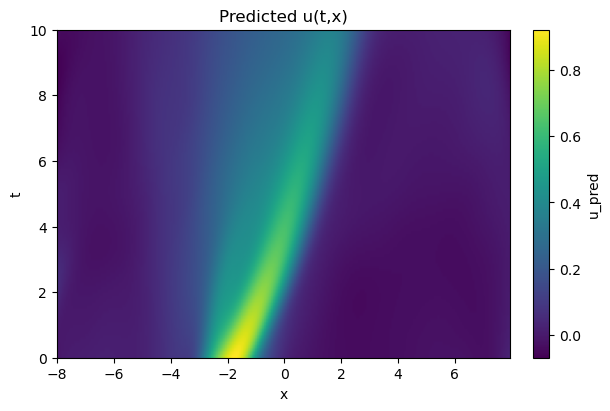

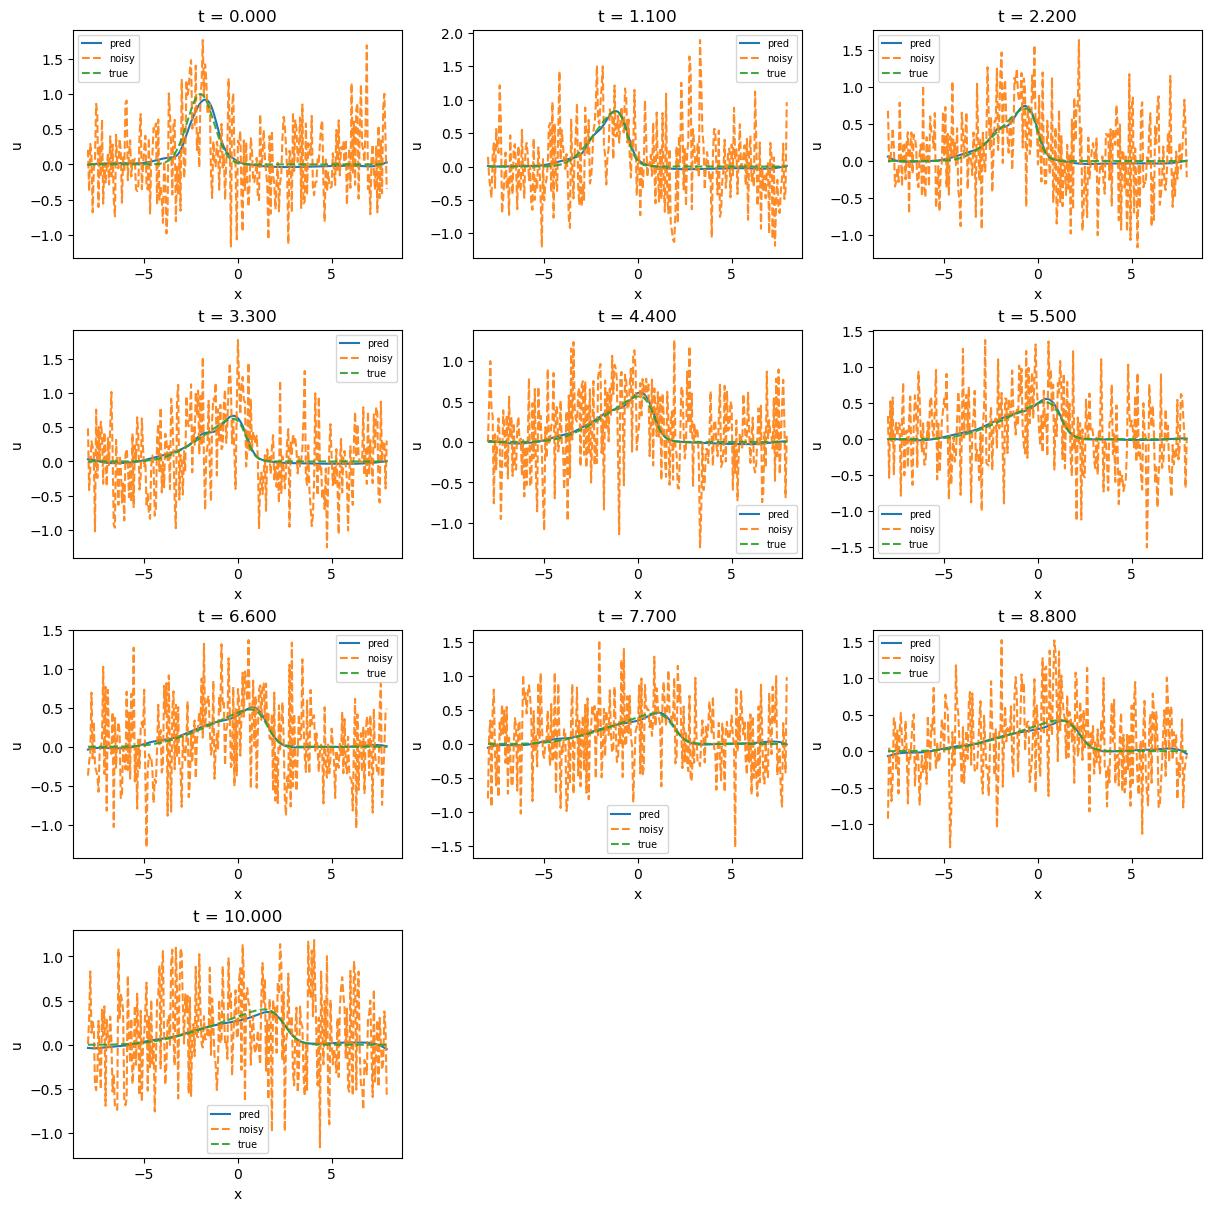

In [8]:
heatmap, plots = hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

In [19]:
out["noise"] = noise

In [22]:
hlprs.save_to_json(train, out, correct_coeffs, path="../ethan_work/SAPINN_scalar_runs/sapinn_scalar_meta.json")

In [82]:
loss, aux = train.compute_loss(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

Now comparing with an earlier version of the model, without Self-Adaptive loss weights

In [23]:
lam_tv = 1e-7
lam_pde = 0.5
lam_data = 10.0

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

u_model_2, symnet_2 = make_models()
pde_trainer = make_trainer(u_model_2, symnet_2)
print("lambda_tv:", pde_trainer.cfg.lambda_tv)

lambda_tv: 1e-07


In [24]:
out = None
for i in range(12000):
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = pde_trainer.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

    if (i + 1)%500==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_data: {out["loss_data"]:.4f} | loss_tv: {out["loss_tv"]:.4f}  | loss_pde: {out["loss_pde"]:.4f}')

step 500:
loss 2.3438
loss_data: 0.2342 | loss_tv: 0.0960  | loss_pde: 0.0042
step 1000:
loss 2.7290
loss_data: 0.2727 | loss_tv: 0.0999  | loss_pde: 0.0045
step 1500:
loss 2.7896
loss_data: 0.2788 | loss_tv: 0.1060  | loss_pde: 0.0038
step 2000:
loss 2.6259
loss_data: 0.2624 | loss_tv: 0.1019  | loss_pde: 0.0036
step 2500:
loss 2.4554
loss_data: 0.2453 | loss_tv: 0.1086  | loss_pde: 0.0048
step 3000:
loss 2.5636
loss_data: 0.2562 | loss_tv: 0.1028  | loss_pde: 0.0040
step 3500:
loss 2.6142
loss_data: 0.2612 | loss_tv: 0.1128  | loss_pde: 0.0045
step 4000:
loss 2.5024
loss_data: 0.2500 | loss_tv: 0.1059  | loss_pde: 0.0042
step 4500:
loss 2.7158
loss_data: 0.2713 | loss_tv: 0.1211  | loss_pde: 0.0046
step 5000:
loss 2.4850
loss_data: 0.2482 | loss_tv: 0.1039  | loss_pde: 0.0057
step 5500:
loss 2.3647
loss_data: 0.2362 | loss_tv: 0.1096  | loss_pde: 0.0051
step 6000:
loss 2.4955
loss_data: 0.2493 | loss_tv: 0.1005  | loss_pde: 0.0060
step 6500:
loss 2.5636
loss_data: 0.2560 | loss_tv: 0

max_abs_diff = 0.299342


()

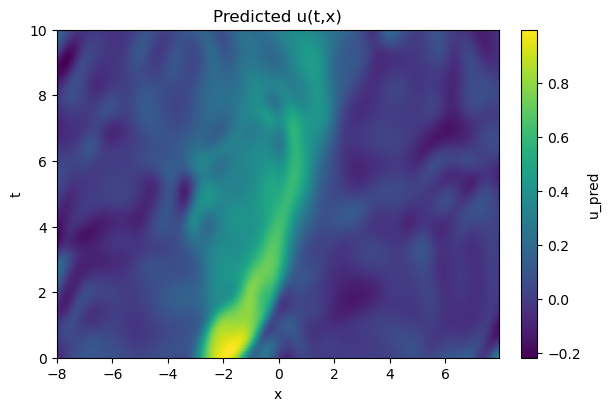

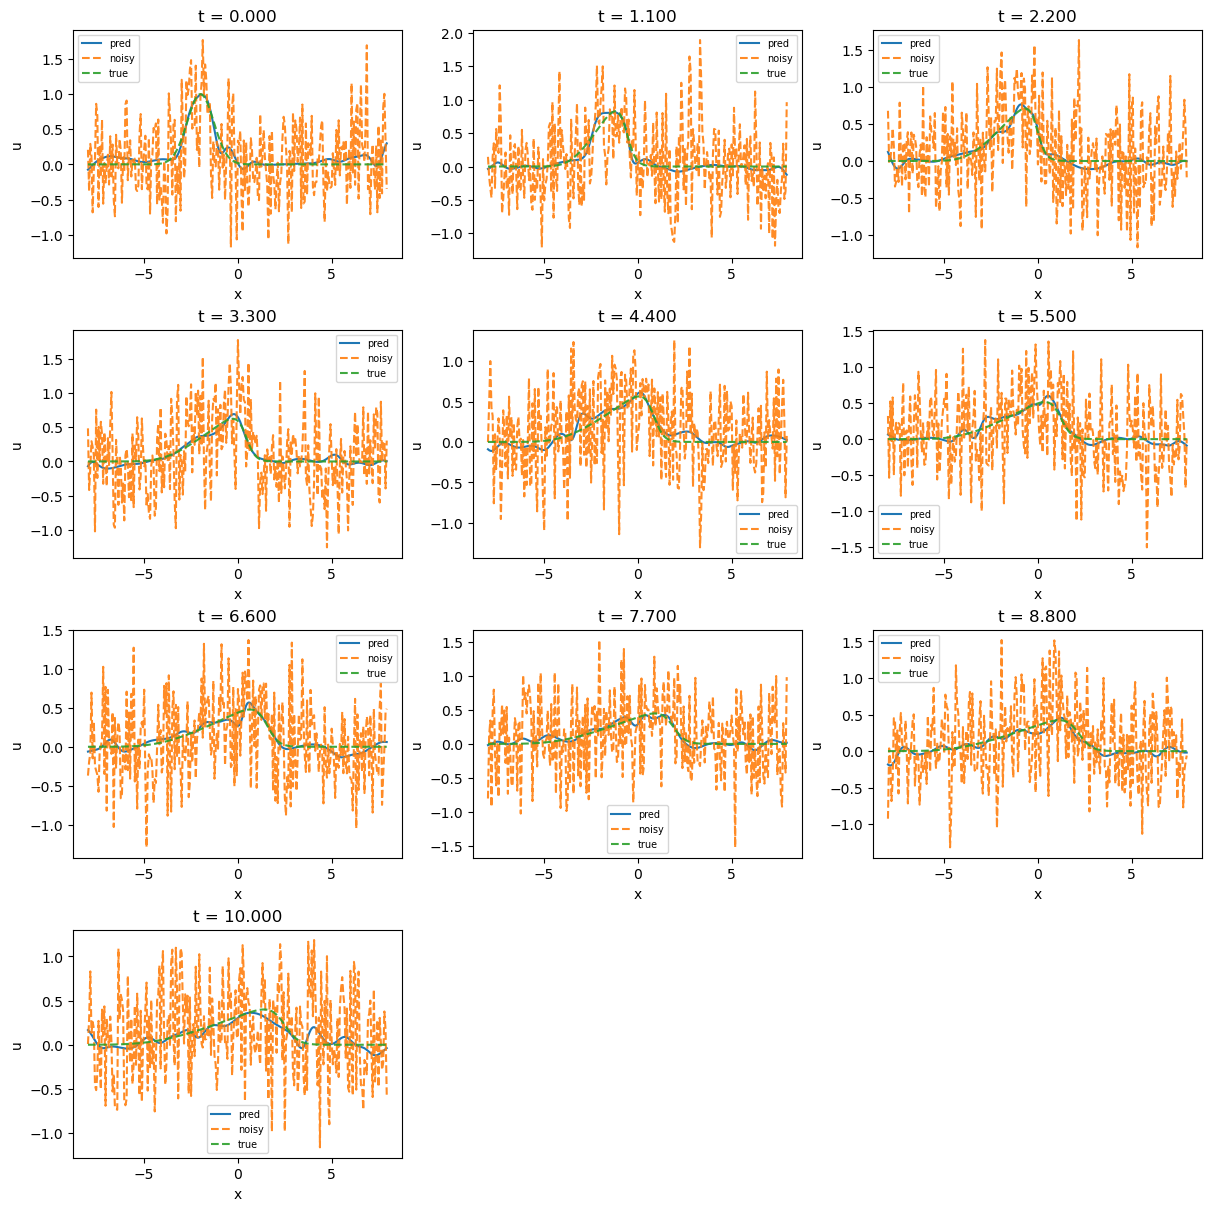

In [29]:
hlprs.snapshot_comp(pde_trainer.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

In [28]:
hlprs.save_to_json(pde_trainer, out, correct_coeffs, path="../ethan_work/SAPINN_scalar_runs/old_model_meta.json")